# Fund Formation EDA

Annual new fund formation counts using three complementary sources.

**Data sources:**
1. `wrdssec.wrds_vc_formd` — Form D pooled investment funds (2009–2020)
2. `wrdssec.wrds_forms` — EDGAR N-2 closed-end fund registrations (1993–present)
3. `wrdssec.wrds_forms` — Form ADV investment adviser filings (2000–present)
4. SEC EDGAR quarterly TSV — Post-2020 Form D funds supplement

**Reference:** `references/fund-formation.md`, `references/formd.md`

## Contents
1. Form D: pooled investment fund filings (3C.1, 3C.7, 506b, 506c)
2. Post-2020 Form D from SEC EDGAR TSV
3. EDGAR N-2: closed-end fund IPO registrations
4. Form ADV: investment adviser registrations
5. Combined visualization: fund formation practice area

In [1]:
import psycopg2
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import io
import time
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

conn = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu',
    port=9737,
    database='wrds',
    user='eddyhu',
    sslmode='require'
)
print('Connected to WRDS')

Connected to WRDS


## 1. Form D: Pooled Investment Funds (2009–2020)

In [2]:
# First: check available industry group types
query_types = """
SELECT industrygrouptype,
       COUNT(DISTINCT accession) AS n_unique_filings
FROM wrdssec.wrds_vc_formd
WHERE submissiontype = 'D'
  AND isamendment = 'false'
GROUP BY industrygrouptype
ORDER BY n_unique_filings DESC
"""
df_types = pd.read_sql(query_types, conn)
print('Industry group types in Form D:')
print(df_types.to_string(index=False))

/Users/vwh7mb/.tmp/ipykernel_85037/3388818972.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_types = pd.read_sql(query_types, conn)


Industry group types in Form D:
                   industrygrouptype  n_unique_filings
              Pooled Investment Fund             73025
                    Other Technology             39030
                               Other             38990
                   Other Health Care             11529
                          Commercial             10997
                   Other Real Estate              8838
                       Biotechnology              7872
                         Residential              6970
                         Oil and Gas              6593
                   REITS and Finance              5470
                           Investing              5367
                       Manufacturing              4905
Other Banking and Financial Services              4096
                           Retailing              3347
                        Other Energy              3301
                     Pharmaceuticals              3120
                   Business Servi

In [3]:
# Annual new fund filings by exemption type (2009–2020)
query_funds = """
SELECT
    ('20' || LPAD(SPLIT_PART(accession, '-', 2), 2, '0'))::int AS filing_year,
    exempt_item,
    COUNT(DISTINCT accession)   AS n_new_funds,
    SUM(
        CASE WHEN totalamountsold ~ '^[0-9]+$'
             THEN LEAST(totalamountsold::numeric, 5e9)
             ELSE 0
        END
    ) / 1e9                     AS total_raised_capped_bn
FROM wrdssec.wrds_vc_formd
WHERE submissiontype = 'D'
  AND isamendment = 'false'
  AND industrygrouptype IN ('Pooled Investment Fund', 'Investment Fund')
  AND ('20' || LPAD(SPLIT_PART(accession, '-', 2), 2, '0'))::int
      BETWEEN 2009 AND 2020
GROUP BY filing_year, exempt_item
ORDER BY filing_year, exempt_item
"""
df_funds = pd.read_sql(query_funds, conn)
print(f'Rows returned: {len(df_funds)}')
print(df_funds.pivot_table(index='filing_year', columns='exempt_item',
                            values='n_new_funds', aggfunc='sum').fillna(0))

/Users/vwh7mb/.tmp/ipykernel_85037/94067818.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_funds = pd.read_sql(query_funds, conn)


Rows returned: 157
exempt_item    04  04.1  04.2  04.3    05     06    06b    06c    3C    3C.1  \
filing_year                                                                    
2009          7.0   1.0   1.0   3.0  14.0  840.0    0.0    0.0  13.0   942.0   
2010          6.0   0.0   0.0   1.0   5.0  844.0    0.0    0.0  12.0  1037.0   
2011          9.0   2.0   0.0   1.0   8.0  839.0    0.0    0.0  12.0  1072.0   
2012          4.0   2.0   0.0   3.0   8.0  793.0    0.0    0.0  16.0  1143.0   
2013         13.0   1.0   0.0   2.0   4.0  570.0  204.0   48.0  11.0  1378.0   
2014          4.0   1.0   0.0   3.0   8.0    0.0  770.0  122.0  11.0  1762.0   
2015          5.0   0.0   0.0   0.0   7.0    0.0  721.0  105.0   4.0  2220.0   
2016          7.0   0.0   0.0   0.0   9.0    0.0  728.0  159.0   6.0  2361.0   
2017          7.0   0.0   0.0   3.0   3.0    0.0  714.0  132.0   5.0  2837.0   
2018          6.0   1.0   0.0   2.0   0.0    0.0  757.0  214.0  10.0  3620.0   
2019          3.0   0

In [4]:
# Focus on institutional funds: 3C.1 (hedge/PE <100 investors) and 3C.7 (QP funds)
df_inst = df_funds[df_funds['exempt_item'].isin(['3C.1', '3C.7'])]
inst_annual = df_inst.groupby('filing_year').agg(
    n_funds=('n_new_funds', 'sum'),
    raised_bn=('total_raised_capped_bn', 'sum')
)

# All pooled investment fund filings
all_funds_annual = df_funds.groupby('filing_year').agg(
    n_funds=('n_new_funds', 'sum'),
    raised_bn=('total_raised_capped_bn', 'sum')
)

print('Institutional fund filings (3C.1 + 3C.7) by year:')
print(inst_annual)
print()
print('All pooled fund filings by year:')
print(all_funds_annual)

Institutional fund filings (3C.1 + 3C.7) by year:
             n_funds    raised_bn
filing_year                      
2009            2483   563.290841
2010            3274   287.205607
2011            3399  2121.945611
2012            3592   318.126209
2013            4308   483.526795
2014            4877   764.168073
2015            5535   641.014208
2016            5645   544.696300
2017            6516   589.678101
2018            7956   668.271607
2019            8160   979.252591
2020            5845   254.078513

All pooled fund filings by year:
             n_funds    raised_bn
filing_year                      
2009            3407   659.534636
2010            4182   333.631680
2011            4304  2149.931758
2012            4456   348.006590
2013            5232   509.049074
2014            5845   802.151095
2015            6456   687.070936
2016            6622   576.792630
2017            7488   656.213787
2018            9077   690.068621
2019            9352  1006.38450

## 2. Post-2020 Form D from SEC EDGAR TSV

In [5]:
import os

CACHE = '/tmp/formd_funds_post2020.parquet'

def download_formd_fund_quarter(year: int, quarter: int) -> pd.DataFrame:
    """Download Form D quarterly TSV and filter to pooled investment funds."""
    url = (f'https://www.sec.gov/files/structureddata/data/'
           f'form-d-data-sets/{year}q{quarter}_d.zip')
    headers = {'User-Agent': 'Edwin Hu ehu@law.virginia.edu'}
    time.sleep(0.6)
    req = urllib.request.Request(url, headers=headers)
    try:
        with urllib.request.urlopen(req, timeout=30) as r:
            content = r.read()
    except Exception as e:
        print(f'  Skipping {year}Q{quarter}: {e}')
        return pd.DataFrame()

    zf = zipfile.ZipFile(io.BytesIO(content))
    sub_fn = [f for f in zf.namelist() if 'FORMDSUBMISSION' in f.upper()][0]
    off_fn = [f for f in zf.namelist() if 'OFFERING' in f.upper()][0]
    sub = pd.read_csv(zf.open(sub_fn), sep='\t', dtype=str)
    off = pd.read_csv(zf.open(off_fn), sep='\t', dtype=str)
    df = sub.merge(off, on='ACCESSIONNUMBER', how='left')
    df = df[(df.get('SUBMISSIONTYPE') == 'D')]
    df = df[(df.get('ISAMENDMENT', 'false') == 'false')]

    # Filter to pooled investment funds
    fund_cols = [c for c in df.columns if 'INDUSTRY' in c.upper() or 'FUND' in c.upper()]
    print(f'  {year}Q{quarter}: {len(df)} new filings; fund cols: {fund_cols}')
    return df

if not os.path.exists(CACHE):
    dfs = []
    for year in range(2021, 2025):
        for quarter in range(1, 5):
            if year == 2024 and quarter > 3:
                continue
            print(f'Downloading {year}Q{quarter}...')
            df_q = download_formd_fund_quarter(year, quarter)
            if len(df_q) > 0:
                df_q['year'] = year
                df_q['quarter'] = quarter
                dfs.append(df_q)
    if dfs:
        df_post2020 = pd.concat(dfs, ignore_index=True)
        df_post2020.to_parquet(CACHE)
        print(f'Cached {len(df_post2020):,} rows to {CACHE}')
    else:
        df_post2020 = pd.DataFrame()
else:
    df_post2020 = pd.read_parquet(CACHE)
    print(f'Loaded from cache: {len(df_post2020):,} rows')

Loaded from cache: 140,421 rows


## 3. EDGAR N-2: Closed-End Fund Registrations

In [6]:
# Annual N-2 closed-end fund initial registrations
query_n2 = """
SELECT
    EXTRACT(YEAR FROM fdate)::int   AS filing_year,
    form AS form_type,
    COUNT(DISTINCT accession)       AS n_registrations,
    COUNT(DISTINCT cik)             AS n_unique_funds
FROM wrdssec.wrds_forms
WHERE form IN ('N-2', 'N-2/A', 'N-2 MEF')
  AND fdate BETWEEN '1993-01-01' AND '2026-12-31'
GROUP BY filing_year, form
ORDER BY filing_year, form_type
"""
df_n2 = pd.read_sql(query_n2, conn)
print('N-2 filings by type and year (recent):')
print(df_n2.tail(20))

/Users/vwh7mb/.tmp/ipykernel_85037/828494384.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_n2 = pd.read_sql(query_n2, conn)


N-2 filings by type and year (recent):
    filing_year form_type  n_registrations  n_unique_funds
46         2017       N-2              132             124
47         2017     N-2/A              197             114
48         2018       N-2              141             135
49         2018     N-2/A              217             126
50         2019       N-2              147             138
51         2019     N-2/A              215             119
52         2020       N-2              177             170
53         2020     N-2/A              168              99
54         2021       N-2              200             183
55         2021     N-2/A              226             130
56         2022       N-2              129             124
57         2022     N-2/A              224             132
58         2023       N-2              121             117
59         2023     N-2/A              169              89
60         2024       N-2              192             183
61         2024  

In [7]:
# Annual new closed-end fund IPOs (N-2 only, not amendments)
df_n2_new = df_n2[df_n2['form_type'] == 'N-2'].set_index('filing_year')[['n_unique_funds']]
df_n2_new.columns = ['cef_ipo_count']

print('Annual closed-end fund IPO registrations:')
print(df_n2_new)

Annual closed-end fund IPO registrations:
             cef_ipo_count
filing_year               
1994                    13
1995                    25
1996                    51
1997                    66
1998                   107
1999                   149
2000                    91
2001                   107
2002                   175
2003                   169
2004                   193
2005                   158
2006                   111
2007                   150
2008                   111
2009                   124
2010                   169
2011                   173
2012                   136
2013                   155
2014                   132
2015                   122
2016                   120
2017                   124
2018                   135
2019                   138
2020                   170
2021                   183
2022                   124
2023                   117
2024                   183
2025                   176
2026                    46


## 4. Form ADV: Investment Adviser Registrations

In [8]:
# Annual ADV filings via WRDS EDGAR index
query_adv = """
SELECT
    EXTRACT(YEAR FROM fdate)::int   AS filing_year,
    form,
    COUNT(DISTINCT accession)       AS n_filings,
    COUNT(DISTINCT cik)             AS n_unique_advisers
FROM wrdssec.wrds_forms
WHERE form IN ('ADV', 'ADV-NR', 'ADV-W', 'ADV-E')
  AND fdate BETWEEN '2000-01-01' AND '2026-12-31'
GROUP BY filing_year, form
ORDER BY filing_year, form
"""
df_adv = pd.read_sql(query_adv, conn)
print('ADV form types (recent years):')
print(df_adv[df_adv['filing_year'] >= 2018].to_string(index=False))

/Users/vwh7mb/.tmp/ipykernel_85037/586816750.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_adv = pd.read_sql(query_adv, conn)


ADV form types (recent years):
 filing_year   form  n_filings  n_unique_advisers
        2018 ADV-NR         90                 77
        2019 ADV-NR         53                 51
        2020 ADV-NR          5                  5
        2021 ADV-NR          4                  2
        2022 ADV-NR          2                  2
        2023 ADV-NR          2                  2


In [9]:
# Net new RIA registrations (new ADV - withdrawals ADV-W)
adv_new = df_adv[df_adv['form'] == 'ADV'].set_index('filing_year')['n_unique_advisers']
adv_withdraw = df_adv[df_adv['form'] == 'ADV-W'].set_index('filing_year')['n_unique_advisers']

adv_summary = pd.DataFrame({
    'new_advisers': adv_new,
    'withdrawals': adv_withdraw
}).fillna(0)
adv_summary['net_new'] = adv_summary['new_advisers'] - adv_summary['withdrawals']

print('Investment Adviser Registrations (recent):')
print(adv_summary.tail(10))

Investment Adviser Registrations (recent):
Empty DataFrame
Columns: [new_advisers, withdrawals, net_new]
Index: []


## 5. Combined Visualization

In [10]:
# Merge all three sources
combined = pd.DataFrame(index=range(2009, 2024))
combined.index.name = 'year'

# Form D: institutional funds (3C.1 + 3C.7)
combined = combined.join(inst_annual['n_funds'].rename('private_fund_3c'), how='left')

# EDGAR N-2
combined = combined.join(df_n2_new['cef_ipo_count'], how='left')

# Form ADV net new (scaled down — not all are fund-launching)
combined = combined.join(adv_summary['net_new'].rename('new_ria_net'), how='left')

combined = combined.fillna(0)
print('Combined fund formation data:')
print(combined)

Combined fund formation data:
      private_fund_3c  cef_ipo_count  new_ria_net
year                                             
2009           2483.0            124          0.0
2010           3274.0            169          0.0
2011           3399.0            173          0.0
2012           3592.0            136          0.0
2013           4308.0            155          0.0
2014           4877.0            132          0.0
2015           5535.0            122          0.0
2016           5645.0            120          0.0
2017           6516.0            124          0.0
2018           7956.0            135          0.0
2019           8160.0            138          0.0
2020           5845.0            170          0.0
2021              0.0            183          0.0
2022              0.0            124          0.0
2023              0.0            117          0.0


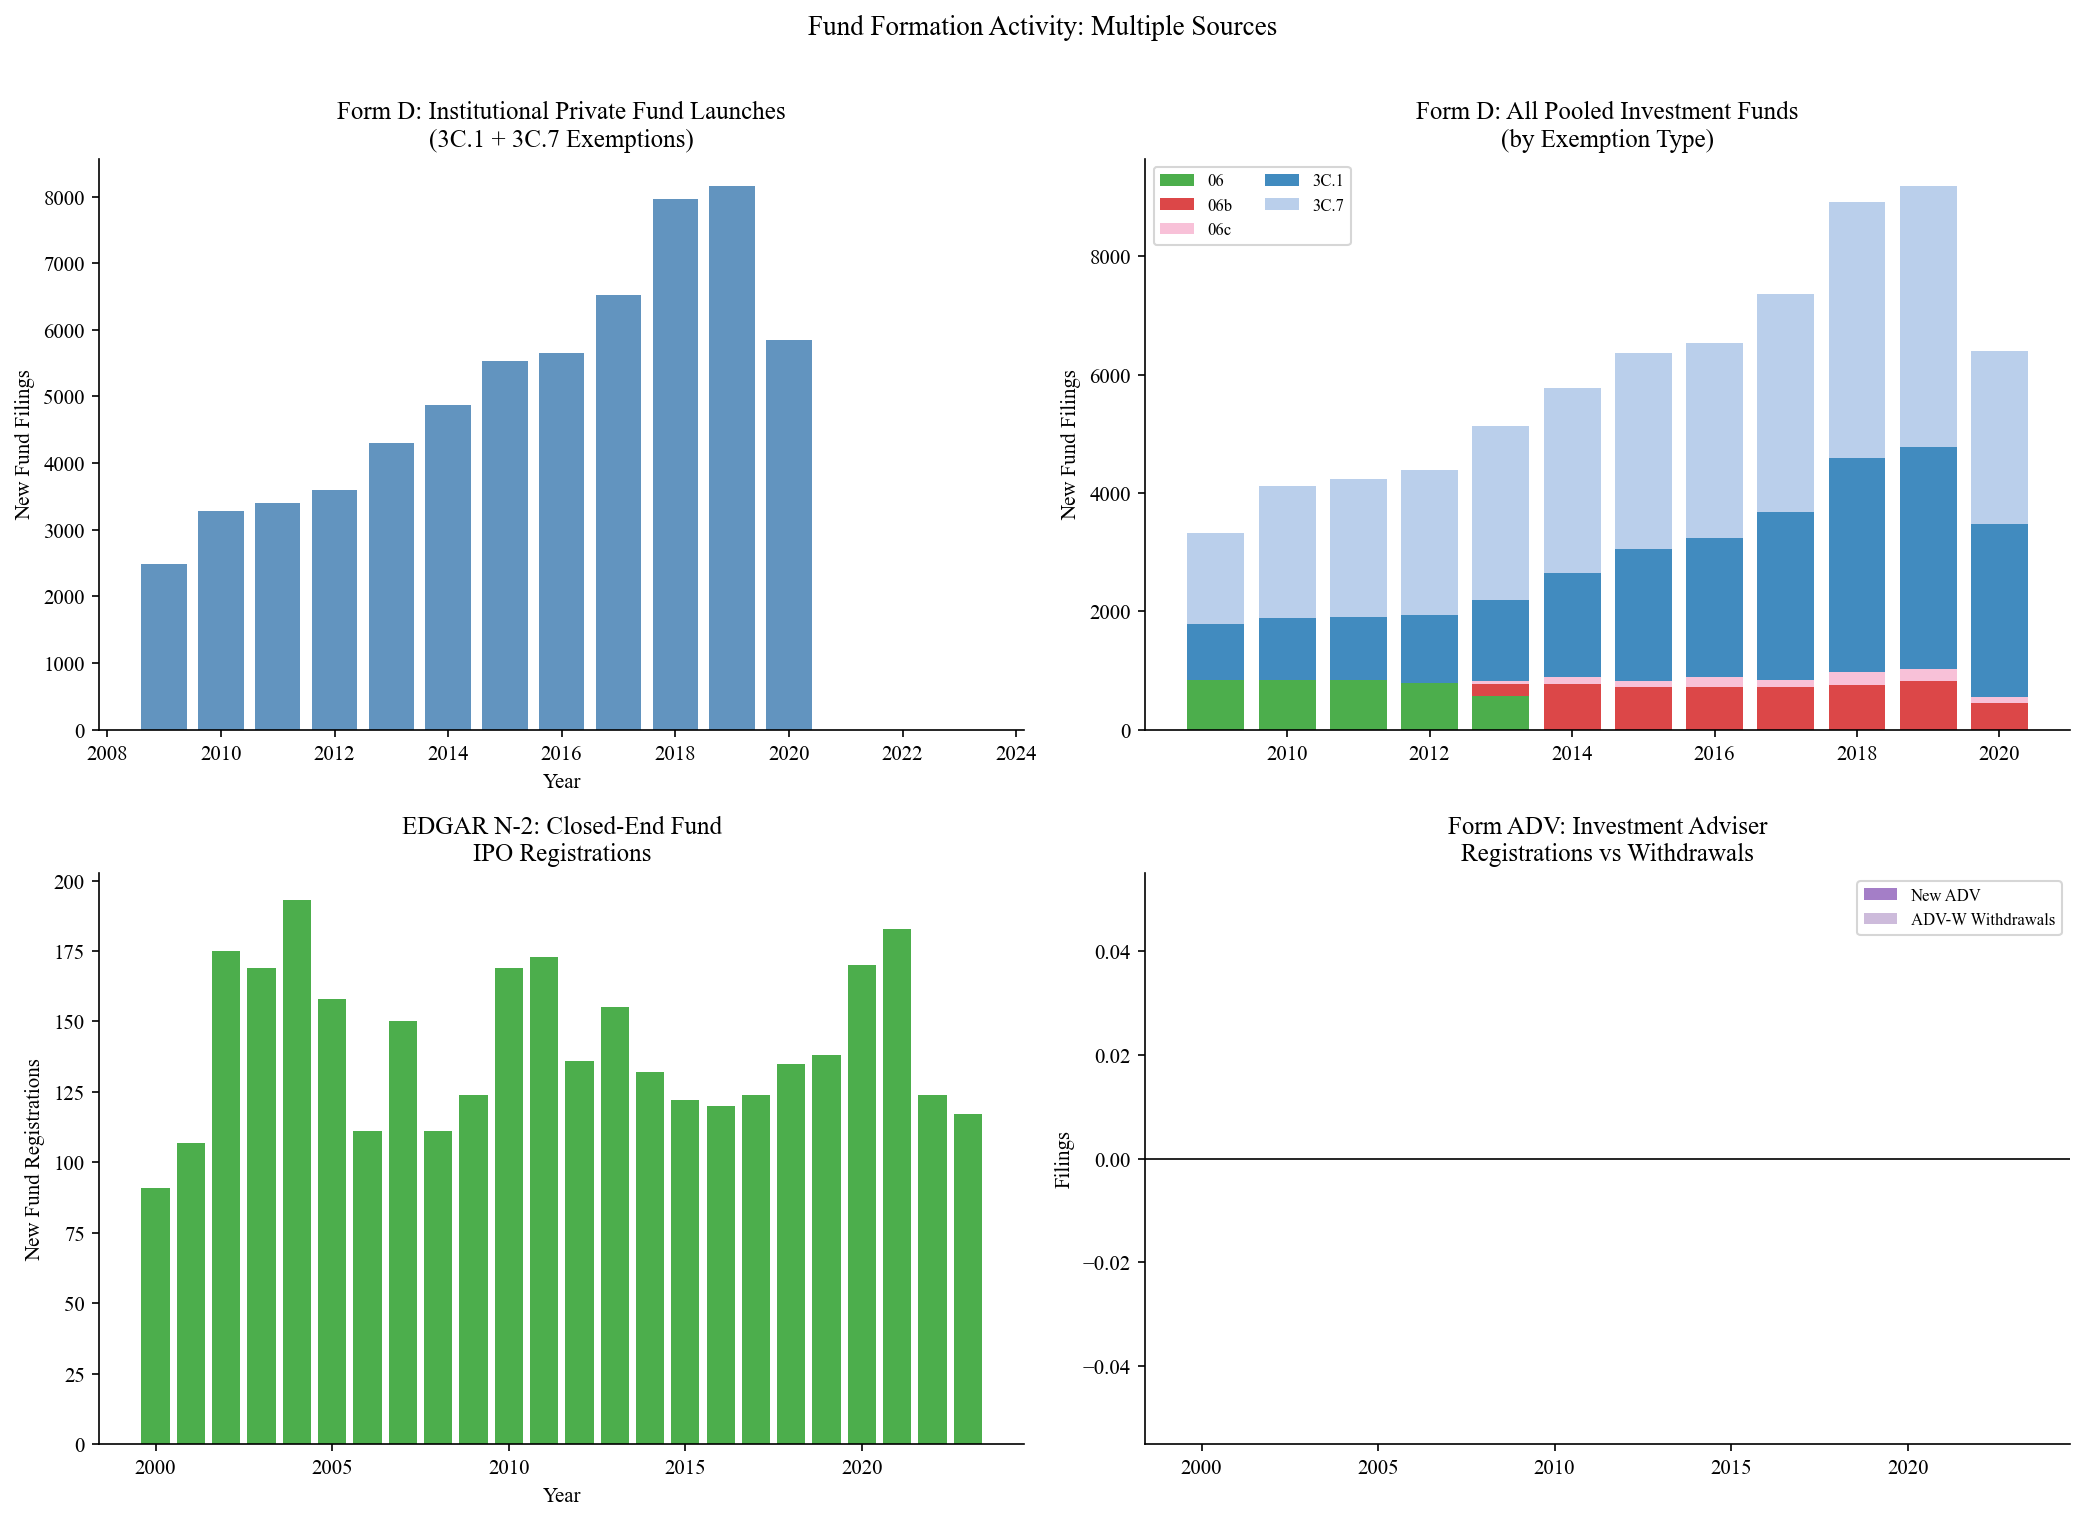

Saved: /tmp/fund_formation.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Form D private fund filings (3C.1 + 3C.7)
ax = axes[0, 0]
ax.bar(combined.index, combined['private_fund_3c'], color='steelblue', alpha=0.85)
ax.set_title('Form D: Institutional Private Fund Launches\n(3C.1 + 3C.7 Exemptions)')
ax.set_ylabel('New Fund Filings')
ax.set_xlabel('Year')

# Panel B: Form D by exemption type (stacked)
ax = axes[0, 1]
fund_pivot = df_funds.pivot_table(index='filing_year', columns='exempt_item',
                                   values='n_new_funds', aggfunc='sum').fillna(0)
fund_pivot = fund_pivot[(fund_pivot.index >= 2009) & (fund_pivot.index <= 2020)]
exempt_colors = {'3C.1': '#1f77b4', '3C.7': '#aec7e8', '06b': '#d62728',
                 '06c': '#f7b6d2', '06': '#2ca02c'}
bottom = np.zeros(len(fund_pivot))
for col in fund_pivot.columns:
    if col in exempt_colors:
        ax.bar(fund_pivot.index, fund_pivot[col], bottom=bottom,
               label=col, color=exempt_colors[col], alpha=0.85)
        bottom += fund_pivot[col].values
ax.set_title('Form D: All Pooled Investment Funds\n(by Exemption Type)')
ax.set_ylabel('New Fund Filings')
ax.legend(fontsize=8, ncol=2)

# Panel C: EDGAR N-2 closed-end fund IPOs
ax = axes[1, 0]
n2_full = df_n2_new.reindex(range(2000, 2024)).fillna(0)
ax.bar(n2_full.index, n2_full['cef_ipo_count'], color='#2ca02c', alpha=0.85)
ax.set_title('EDGAR N-2: Closed-End Fund\nIPO Registrations')
ax.set_ylabel('New Fund Registrations')
ax.set_xlabel('Year')

# Panel D: Form ADV new registrations
ax = axes[1, 1]
adv_full = adv_summary.reindex(range(2000, 2024)).fillna(0)
ax.bar(adv_full.index, adv_full['new_advisers'], color='#9467bd', alpha=0.85,
       label='New ADV')
ax.bar(adv_full.index, -adv_full['withdrawals'], color='#c5b0d5', alpha=0.85,
       label='ADV-W Withdrawals')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Form ADV: Investment Adviser\nRegistrations vs Withdrawals')
ax.set_ylabel('Filings')
ax.legend(fontsize=8)

plt.suptitle('Fund Formation Activity: Multiple Sources', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/fund_formation.png', dpi=150, bbox_inches='tight')
plt.savefig('/tmp/fund_formation.svg', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /tmp/fund_formation.png')

In [12]:
# Summary: recent average
recent = combined[(combined.index >= 2016) & (combined.index <= 2020)]
print('=== Fund Formation Practice Area Summary (2016–2020 avg) ===')
print(f'Private fund launches (3C.1+3C.7): {recent["private_fund_3c"].mean():,.0f}/year')
print(f'CEF IPO registrations (N-2):        {recent["cef_ipo_count"].mean():,.0f}/year')
print(f'Net new RIA registrations (ADV):    {recent["new_ria_net"].mean():,.0f}/year')
print()
print('NOTE: Fund formation is relatively recession-resistant vs IPO/M&A.')
print('PE fund launches track M&A activity; hedge fund launches are more stable.')
print('3C.1 + 3C.7 filings proxy for private fund lawyer workload (formation counsel).')

=== Fund Formation Practice Area Summary (2016–2020 avg) ===
Private fund launches (3C.1+3C.7): 6,824/year
CEF IPO registrations (N-2):        137/year
Net new RIA registrations (ADV):    0/year

NOTE: Fund formation is relatively recession-resistant vs IPO/M&A.
PE fund launches track M&A activity; hedge fund launches are more stable.
3C.1 + 3C.7 filings proxy for private fund lawyer workload (formation counsel).
